# 05 - Preliminary Stacking Ensemble (no tuning)

**Goal:** test the project's proposed ensemble - a **stacking** classifier - against the single models of notebook 04.
Everything is again **untuned** (scikit-learn defaults, `random_state=42`).

> **Beginner note - what is stacking?**
> Imagine five experts (SVM, kNN, Random Forest, Gradient Boosting, Naive Bayes) each giving their opinion on which gas a sample is.
> A **meta-learner** (a logistic regression) learns *how much to trust each expert*, and makes the final decision.
>
> **The catch.** The meta-learner must learn from opinions the experts gave on samples they had **never seen**. Otherwise it would
> learn to trust experts that merely memorised their training data. The usual trick is cross-validation: split the training data,
> train experts on one part, collect their opinions on the other.
>
> **Why this project needs a special version.** Notebook 01 showed that samples from the same batch are near-identical "twins".
> With ordinary *random* folds, every validation sample has twins in the experts' training data, so the experts look far better than
> they will on future data, which is the standard reason to avoid random folds. Our stacker therefore uses **leave-one-batch-out** folds:
> to get opinions for batch 2, the experts are trained only on the other training batches (1 and 3), and so on.
> If there is only one training batch (protocol P2) that is impossible, so it falls back to ordinary stratified 5-fold.

We compare two versions to measure the effect of this design decision (we do **not** assume in advance which one wins):
* **Stacking (batch CV)** - leave-one-batch-out folds (our leakage-safe version)
* **Stacking (random CV)** - ordinary random folds (the leaky version, as an ablation)

Protocols: **P1** (train B1-3) and **P2** (train B1). The rolling protocol P3 is much more expensive for stacking
(every split refits five models many times) and is left for the final, tuned-stacking step.

In [1]:
import os, sys, time, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from src.data import load_all
from src.models import default_models
from src.evaluate import evaluate_grid, summarize
from src.stacking import BatchStackingClassifier, make_stackers, BASE_NAMES
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS, SEQ
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
X, y, batch = load_all()

all_models = default_models()
def base_models(): return [(n, default_models()[n]) for n in BASE_NAMES]
stackers = make_stackers()
print("base models:", BASE_NAMES, "| meta-learner: LogisticRegression (default)")

base models: ['SVM', 'kNN', 'Random Forest', 'Gradient Boosting', 'Naive Bayes'] | meta-learner: LogisticRegression (default)


## 1. Run the stackers

2 stackers x 3 feature pipelines (`raw`, `PCA`, `LDA`) x 2 protocols = 12 runs. As in notebook 04, the *same* pipeline wraps the stacker:
scaling (and PCA/LDA) is fitted on the training batches only, then the five base models and the meta-learner are trained on that.

In [2]:
CACHE = RES / "05_stacking_results.csv"
RERUN = False        # True recomputes (also available as: python scripts/run_stacking.py); see 05_runtime_seconds.txt for the duration
if CACHE.exists() and not RERUN:
    stk = pd.read_csv(CACHE)
    print(f"loaded saved results ({len(stk)} rows); original run took {int(open(RES / '05_runtime_seconds.txt').read())} s")
else:
    t0 = time.time()
    stk = evaluate_grid(stackers, X, y, batch, variants=("raw", "PCA", "LDA"), protocols=("P1", "P2"), split_level=True)
    open(RES / "05_runtime_seconds.txt", "w").write(str(int(time.time() - t0)))
    stk.to_csv(CACHE, index=False); print(f"done in {time.time() - t0:.0f} s | rows: {len(stk)}")

base = pd.read_csv(RES / "04_baselines_results.csv")                     # notebook 04 (same models, same settings)
base = base[base.model.isin(BASE_NAMES + ["Majority class"]) & base.protocol.isin(["P1", "P2"])]
res = pd.concat([base, stk], ignore_index=True)
summ = summarize(res); summ.to_csv(RES / "05_stacking_summary.csv", index=False)

loaded saved results (96 rows); original run took 1364 s


## 2. Headline: stacking vs its five experts

Mean macro-F1 over the test batches (darker = better). The first five rows are the single models from notebook 04.

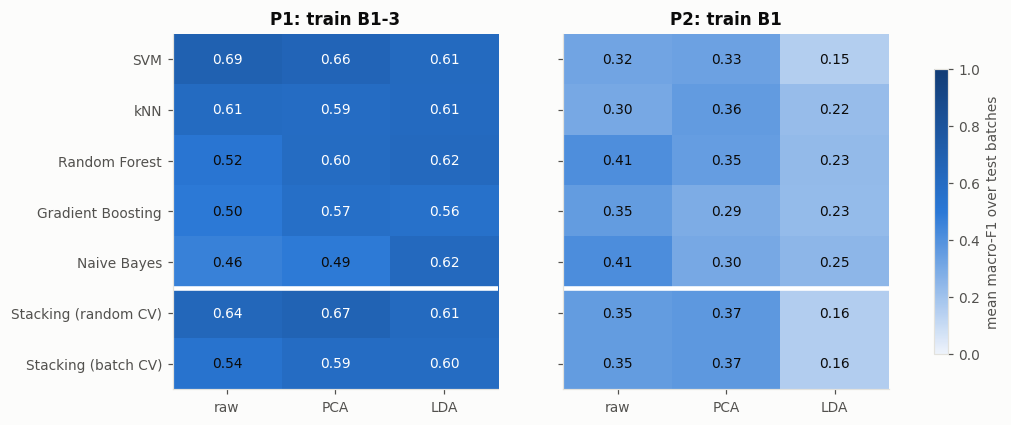


P1


mean_accuracy  mean_macro_f1  weighted_accuracy  \
model                variant                                                    
SVM                  raw              0.705          0.690              0.608   
                     PCA              0.666          0.660              0.563   
                     LDA              0.666          0.614              0.602   
kNN                  raw              0.615          0.609              0.581   
                     PCA              0.601          0.594              0.571   
                     LDA              0.640          0.610              0.559   
Random Forest        raw              0.573          0.518              0.514   
                     PCA              0.646          0.599              0.572   
                     LDA              0.647          0.625              0.572   
Gradient Boosting    raw              0.531          0.495              0.475   
                     PCA              0.624          0.570              0.551   
                     LDA              0.567          0.556              0.477   
Naive Bayes          raw              0.506          0.461              0.447   
                     PCA              0.563          0.490              0.435   
                     LDA              0.632          0.621              0.614   
Stacking (random CV) raw              0.688          0.640              0.593   
                     PCA              0.708          0.673              0.619   
                     LDA              0.650          0.614              0.583   
Stacking (batch CV)  raw              0.562          0.540              0.549   
                     PCA              0.619          0.594              0.550   
                     LDA              0.620          0.600              0.532   

                              weighted_macro_f1  min_macro_f1  
model                variant                                   
SVM                  raw                  0.579         0.431  
                     PCA                  0.552         0.450  
                     LDA                  0.556         0.404  
kNN                  raw                  0.558         0.464  
                     PCA                  0.547         0.441  
                     LDA                  0.532         0.349  
Random Forest        raw                  0.467         0.175  
                     PCA                  0.514         0.393  
                     LDA                  0.551         0.284  
Gradient Boosting    raw                  0.437         0.218  
                     PCA                  0.499         0.336  
                     LDA                  0.466         0.272  
Naive Bayes          raw                  0.412         0.099  
                     PCA                  0.385         0.197  
                     LDA                  0.597         0.264  
Stacking (random CV) raw                  0.556         0.420  
                     PCA                  0.583         0.509  
                     LDA                  0.555         0.388  
Stacking (batch CV)  raw                  0.530         0.231  
                     PCA                  0.527         0.430  
                     LDA                  0.504         0.268


P2


mean_accuracy  mean_macro_f1  weighted_accuracy  \
model                variant                                                    
SVM                  raw              0.390          0.316              0.411   
                     PCA              0.429          0.331              0.431   
                     LDA              0.211          0.151              0.225   
kNN                  raw              0.365          0.303              0.395   
                     PCA              0.426          0.358              0.432   
                     LDA              0.231          0.220              0.240   
Random Forest        raw              0.487          0.410              0.465   
                     PCA              0.444          0.351              0.444   
                     LDA              0.249          0.233              0.263   
Gradient Boosting    raw              0.458          0.355              0.455   
                     PCA              0.386          0.289              0.426   
                     LDA              0.269          0.227              0.297   
Naive Bayes          raw              0.484          0.413              0.467   
                     PCA              0.340          0.301              0.325   
                     LDA              0.289          0.249              0.264   
Stacking (random CV) raw              0.461          0.352              0.480   
                     PCA              0.465          0.370              0.504   
                     LDA              0.207          0.156              0.202   
Stacking (batch CV)  raw              0.461          0.352              0.480   
                     PCA              0.465          0.370              0.504   
                     LDA              0.207          0.156              0.202   

                              weighted_macro_f1  min_macro_f1  
model                variant                                   
SVM                  raw                  0.331         0.213  
                     PCA                  0.345         0.059  
                     LDA                  0.163         0.032  
kNN                  raw                  0.330         0.126  
                     PCA                  0.368         0.121  
                     LDA                  0.231         0.080  
Random Forest        raw                  0.376         0.184  
                     PCA                  0.352         0.045  
                     LDA                  0.247         0.115  
Gradient Boosting    raw                  0.355         0.095  
                     PCA                  0.317         0.030  
                     LDA                  0.262         0.034  
Naive Bayes          raw                  0.380         0.195  
                     PCA                  0.300         0.077  
                     LDA                  0.242         0.132  
Stacking (random CV) raw                  0.377         0.166  
                     PCA                  0.421         0.078  
                     LDA                  0.154         0.030  
Stacking (batch CV)  raw                  0.377         0.166  
                     PCA                  0.421         0.078  
                     LDA                  0.154         0.030

In [3]:
order = BASE_NAMES + ["Stacking (random CV)", "Stacking (batch CV)"]
def tab(proto, col="mean_macro_f1"):
    t = summ[summ.protocol == proto].pivot(index="model", columns="variant", values=col).reindex(order)
    return t[["raw", "PCA", "LDA"]]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, proto in zip(axes, ["P1", "P2"]):
    t = tab(proto); im = ax.imshow(t.values, cmap=SEQ, vmin=0, vmax=1, aspect="auto"); ax.grid(False)
    ax.set_xticks(range(3)); ax.set_xticklabels(t.columns); ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index)
    for i in range(t.shape[0]):
        for j in range(3):
            v = t.values[i, j]; ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if v > 0.55 else INK)
    ax.axhline(4.5, color="white", lw=3)
    ax.set_title({"P1": "P1: train B1-3", "P2": "P2: train B1"}[proto])
fig.colorbar(im, ax=axes, shrink=0.8, label="mean macro-F1 over test batches")
fig.savefig(FIG / "17_stacking_heatmap.png"); plt.show()

for proto in ["P1", "P2"]:
    s = summ[(summ.protocol == proto) & summ.model.isin(order)].set_index(["model", "variant"])
    print(f"\n{proto}")
    display(s[["mean_accuracy", "mean_macro_f1", "weighted_accuracy", "weighted_macro_f1", "min_macro_f1"]].reindex(
        [(m, v) for m in order for v in ["raw", "PCA", "LDA"]]).round(3))

## 3. Batch by batch (raw features)

The thick black line is our stacking ensemble. The thin lines are its five experts. If stacking works, the black line should stay
near the best expert on every batch and not just on average.

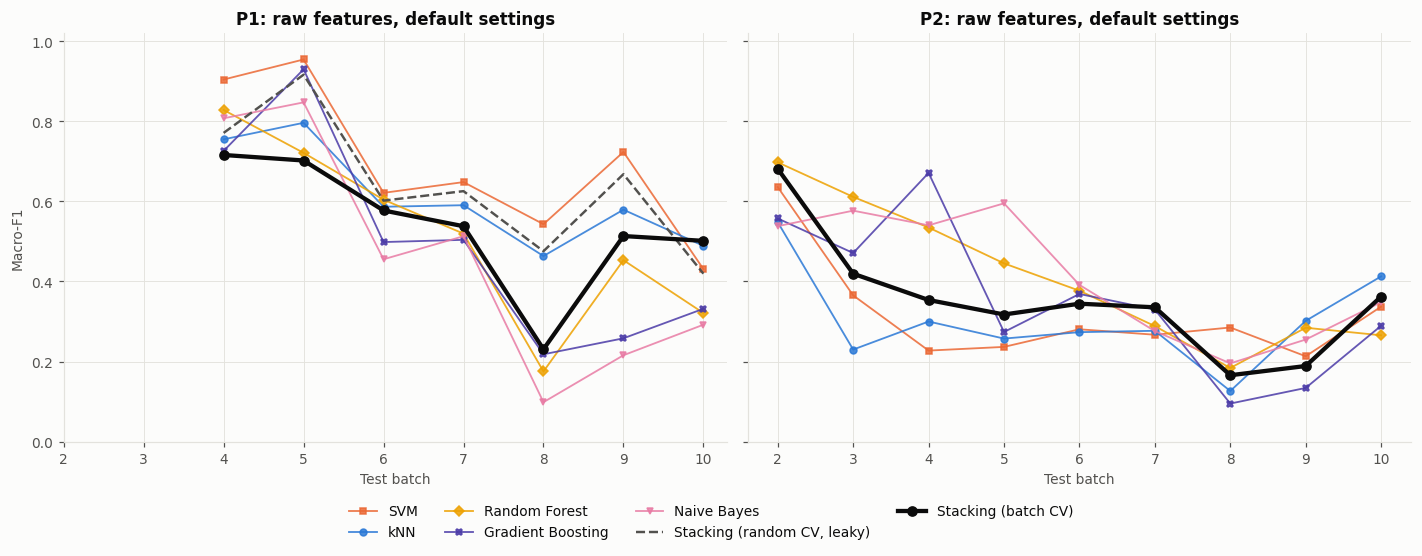

,near (B4-5),far (B8-10),drop
model,,,
SVM,0.930,0.566,0.364
Stacking (batch CV),0.709,0.415,0.294
Stacking (random CV),0.844,0.521,0.323


In [4]:
col = {m: SERIES[i] for i, m in enumerate(all_models)}; mk = {m: MARKERS[i] for i, m in enumerate(all_models)}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, proto in zip(axes, ["P1", "P2"]):
    for m in BASE_NAMES:
        d = res[(res.model == m) & (res.protocol == proto) & (res.variant == "raw")]
        ax.plot(d.test_batch, d.macro_f1, color=col[m], marker=mk[m], ms=4.5, lw=1.2, alpha=0.85, label=m)
    d = res[(res.model == "Stacking (random CV)") & (res.protocol == proto) & (res.variant == "raw")]
    ax.plot(d.test_batch, d.macro_f1, color=INK2, ls="--", lw=1.6, label="Stacking (random CV, leaky)")
    d = res[(res.model == "Stacking (batch CV)") & (res.protocol == proto) & (res.variant == "raw")]
    ax.plot(d.test_batch, d.macro_f1, color=INK, marker="o", ms=6, lw=2.8, label="Stacking (batch CV)")
    ax.set_title(f"{proto}: raw features, default settings"); ax.set_xlabel("Test batch"); ax.set_xticks(range(2, 11)); ax.set_ylim(0, 1.02)
axes[0].set_ylabel("Macro-F1")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); fig.savefig(FIG / "18_stacking_per_batch.png"); plt.show()

r = res[(res.protocol == "P1") & (res.variant == "raw") & res.model.isin(["SVM", "Stacking (batch CV)", "Stacking (random CV)"])]
nf = pd.DataFrame({"near (B4-5)": r[r.test_batch.isin([4, 5])].groupby("model").macro_f1.mean(),
                   "far (B8-10)": r[r.test_batch.isin([8, 9, 10])].groupby("model").macro_f1.mean()})
nf["drop"] = nf["near (B4-5)"] - nf["far (B8-10)"]; nf.to_csv(RES / "05_near_vs_far_P1.csv"); display(nf.round(3))

## 4. Whom does the meta-learner trust?

We fit each stacker once on batches 1-3 (scaling only) and read the meta-learner's coefficients: the share of its total weight that
goes to each expert. The question is simply whether the two fold designs make the meta-learner trust different experts.

,Stacking (batch CV),Stacking (random CV)
SVM,15.4,19.0
kNN,26.0,22.1
Random Forest,22.0,28.0
Gradient Boosting,17.6,21.7
Naive Bayes,19.1,9.2


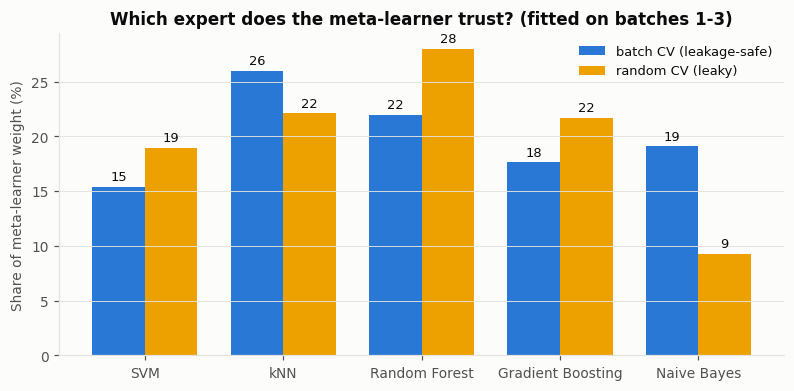

In [5]:
WCACHE = RES / "05_meta_weights.csv"
if WCACHE.exists() and not RERUN:
    W = pd.read_csv(WCACHE, index_col=0)          # fitting two full stackers takes ~15 min (Gradient Boosting is slow)
else:
    Z = StandardScaler().fit(X[batch <= 3]).transform(X[batch <= 3])
    tr_y, tr_b = y[batch <= 3], batch[batch <= 3]
    w = {}
    for name, st in stackers.items():
        fitted = BatchStackingClassifier(base_models(), cv_strategy=st.cv_strategy, n_jobs=-1).fit(Z, tr_y, groups=tr_b)
        w[name] = fitted.base_weights(); print(name, "| folds used:", fitted.cv_strategy_used_, fitted.n_folds_)
    W = pd.DataFrame(w).reindex(BASE_NAMES); W.to_csv(WCACHE)
display((W * 100).round(1))

fig, ax = plt.subplots(figsize=(8.5, 3.8)); xs = np.arange(len(BASE_NAMES)); bw = 0.38
ax.bar(xs - bw / 2, W["Stacking (batch CV)"] * 100, bw, color=SERIES[0], label="batch CV (leakage-safe)")
ax.bar(xs + bw / 2, W["Stacking (random CV)"] * 100, bw, color=SERIES[3], label="random CV (leaky)")
for i, m in enumerate(BASE_NAMES):
    ax.text(i - bw / 2, W.loc[m, "Stacking (batch CV)"] * 100 + 0.6, f"{W.loc[m, 'Stacking (batch CV)'] * 100:.0f}", ha="center", fontsize=8.5)
    ax.text(i + bw / 2, W.loc[m, "Stacking (random CV)"] * 100 + 0.6, f"{W.loc[m, 'Stacking (random CV)'] * 100:.0f}", ha="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels(BASE_NAMES); ax.set_ylabel("Share of meta-learner weight (%)"); ax.grid(axis="x", visible=False)
ax.set_title("Which expert does the meta-learner trust? (fitted on batches 1-3)"); ax.legend(frameon=False, fontsize=8.5)
fig.savefig(FIG / "19_meta_weights.png"); plt.show()

## 5. Diagnostic: why is the leakage-safe stacker not better?

In P1 the leakage-safe stacker (batch CV) is **worse** than both its best expert and the random-fold stacker. Before accepting that, we look
inside. To keep this quick we use a **fast subset of experts (SVM, kNN, Random Forest, Naive Bayes - no Gradient Boosting)**; the question is
whether the same pattern appears and where it comes from.

**(a)** How good are the out-of-fold predictions the meta-learner learns from? With leave-one-batch-out, each expert is trained on *two* training
batches and predicts the third. **(b)** What does the batch-fold stacker get wrong on test batches 5 and 8?

In [6]:
from sklearn.base import clone
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.model_selection import LeaveOneGroupOut
fast = [n for n in BASE_NAMES if n != "Gradient Boosting"]
fast_models = lambda: [(n, default_models()[n]) for n in fast]
tr = batch <= 3
Zs = StandardScaler().fit(X[tr]).transform(X); ytr, gtr = y[tr], batch[tr]

# (a) quality of the out-of-fold predictions
rows = []
for tr_i, va_i in LeaveOneGroupOut().split(Zs[tr], ytr, gtr):
    r = {"held-out batch": int(gtr[va_i][0]), "experts trained on": len(tr_i), "Toluene samples in that training set": int((ytr[tr_i] == 6).sum())}
    for n in fast:
        m = clone(default_models()[n]).fit(Zs[tr][tr_i], ytr[tr_i]); r[n] = round(accuracy_score(ytr[va_i], m.predict(Zs[tr][va_i])), 3)
    rows.append(r)
oof = pd.DataFrame(rows); oof.to_csv(RES / "05_oof_quality.csv", index=False)
print("Accuracy of each expert on the held-out training batch (trained on the other two batches):"); display(oof)

# does the batch-vs-random gap replicate with the fast subset?
fitted = {cv: BatchStackingClassifier(fast_models(), cv_strategy=cv, n_jobs=-1).fit(Zs[tr], ytr, groups=gtr) for cv in ("batch", "random")}
def f1b(pred, tb):
    te = batch == tb; return f1_score(y[te], pred(Zs[te]), labels=np.unique(y[te]), average="macro", zero_division=0)
rows = {}
for cv, st in fitted.items(): rows[f"stack ({cv} CV)"] = {tb: f1b(st.predict, tb) for tb in range(4, 11)}
for n in fast:
    m = clone(default_models()[n]).fit(Zs[tr], ytr); rows[n] = {tb: f1b(m.predict, tb) for tb in range(4, 11)}
fastdf = pd.DataFrame(rows).T; fastdf["mean"] = fastdf.mean(axis=1); fastdf.to_csv(RES / "05_fast_subset_P1.csv")
print("Macro-F1 by test batch, fast subset (P1, raw):"); display(fastdf.round(3))

  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Accuracy of each expert on the held-out training batch (trained on the other two batches):


,held-out batch,experts trained on,Toluene samples in that training set,SVM,kNN,Random Forest,Naive Bayes
0,1,2830,5,0.537,0.847,0.593,0.456
1,2,2031,74,0.973,0.979,0.953,0.749
2,3,1689,79,0.885,0.864,0.929,0.813


Macro-F1 by test batch, fast subset (P1, raw):


,4,5,6,7,8,9,10,mean
stack (batch CV),0.696,0.675,0.581,0.573,0.334,0.532,0.504,0.556
stack (random CV),0.879,0.897,0.587,0.601,0.491,0.652,0.439,0.649
SVM,0.905,0.955,0.621,0.648,0.543,0.724,0.431,0.690
kNN,0.755,0.796,0.587,0.591,0.464,0.579,0.489,0.609
Random Forest,0.828,0.721,0.604,0.520,0.175,0.453,0.321,0.518
Naive Bayes,0.808,0.847,0.456,0.513,0.099,0.216,0.292,0.461


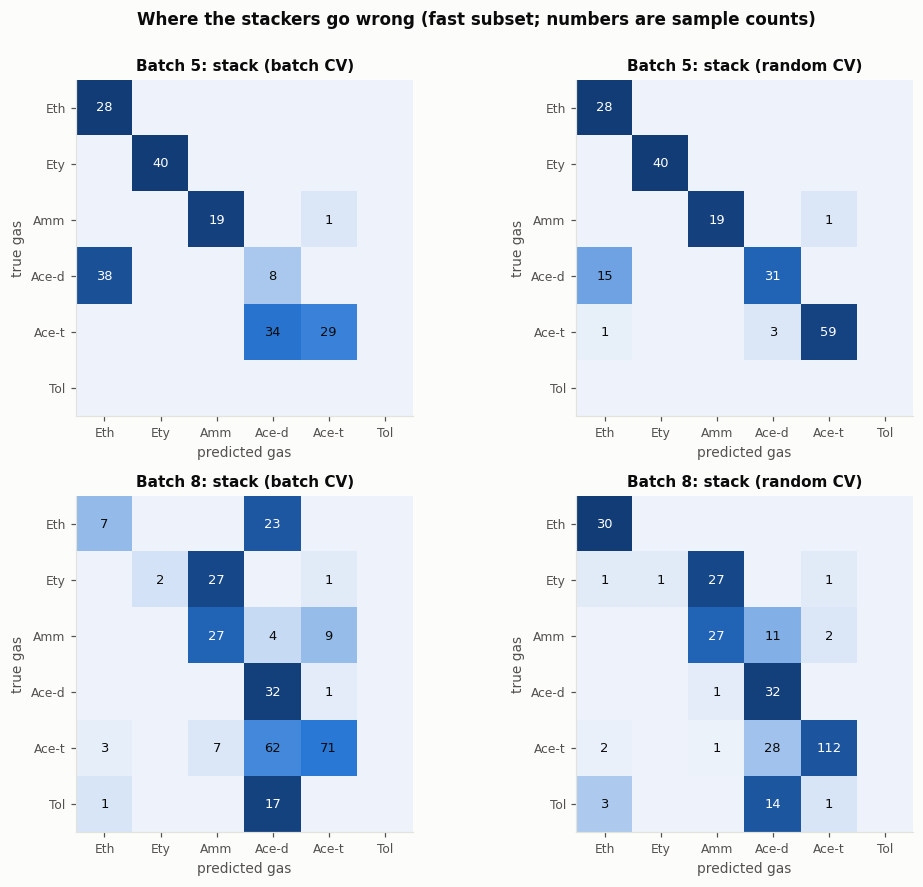

In [7]:
# (b) confusion matrices on test batches 5 and 8
short = ["Eth", "Ety", "Amm", "Ace-d", "Ace-t", "Tol"]
fig, axes = plt.subplots(2, 2, figsize=(9.5, 8))
for i, tb in enumerate((5, 8)):
    te = batch == tb
    for j, cv in enumerate(("batch", "random")):
        cm = confusion_matrix(y[te], fitted[cv].predict(Zs[te]), labels=range(1, 7)); ax = axes[i, j]
        rn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        ax.imshow(rn, cmap=SEQ, vmin=0, vmax=1); ax.grid(False)
        for a in range(6):
            for b_ in range(6):
                if cm[a, b_]: ax.text(b_, a, cm[a, b_], ha="center", va="center", fontsize=8.5, color="white" if rn[a, b_] > 0.55 else INK)
        ax.set_xticks(range(6)); ax.set_xticklabels(short, fontsize=8); ax.set_yticks(range(6)); ax.set_yticklabels(short, fontsize=8)
        ax.set_title(f"Batch {tb}: stack ({cv} CV)", fontsize=10); ax.set_xlabel("predicted gas"); ax.set_ylabel("true gas")
fig.suptitle("Where the stackers go wrong (fast subset; numbers are sample counts)", y=1.0, fontsize=11, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "20_stacking_confusions.png"); plt.show()

## 6. Key takeaways

All models are untuned defaults. Numbers are the mean over test batches. Protocol P1 = train on batches 1-3; P2 = train on batch 1.

| P1: accuracy / macro-F1 | raw | PCA | LDA |
|---|---|---|---|
| **SVM (best single model)** | **70.5% / 69.0%** | 66.6% / 66.0% | 66.6% / 61.4% |
| Stacking, random CV (leaky) | 68.8% / 64.0% | 70.8% / 67.3% | 65.0% / 61.4% |
| Stacking, batch CV (leakage-safe) | 56.2% / 54.0% | 61.9% / 59.4% | 62.0% / 60.0% |

1. **In this preliminary setting, stacking does not beat the best single model.** Under P1 the leakage-safe stacker reaches 54.0% macro-F1 (raw), 15 points below SVM (69.0%). Even the leaky random-fold stacker only matches SVM on accuracy (70.8% with PCA vs 70.5%) and stays below it on macro-F1 (67.3% vs 69.0%). Under P2 the stacker (35.2% raw, 37.0% with PCA macro-F1) lands in the middle of its experts: above SVM and kNN, below Naive Bayes (41.3%) and Random Forest (41.0%). **No gain from stacking can be claimed yet.**
2. **The leakage-safe fold design did not help; it hurt.** Batch folds were expected to give a more honest meta-learner, but the batch-CV stacker is worse than the random-CV one on batches 4-9 (e.g. batch 5: 70.2% vs 91.7% macro-F1; batch 8: 23.1% vs 47.6%) and better only on batch 10 (50.2% vs 42.0%). Random folds are still a leaky *evaluation* method; the point here is that using them to train the *meta-learner* happened to work better with these defaults. Under P2 the two versions are identical (a single training batch forces the same stratified fallback), which confirms the code path.
3. **Diagnosis (fast subset of four experts, same pattern: 55.6% batch CV vs 64.9% random CV).** The out-of-fold predictions that the batch-CV meta-learner learns from are very uneven. When batch 1 is held out, the experts are trained on batches 2-3 only (just 5 Toluene samples) and SVM reaches only 53.7% accuracy there, versus 97.3% when batch 2 is held out. That fold also asks the experts to predict the *past* from the *future*. The batch-fold stacker then learns specific, drift-dependent corrections that do not transfer: on batch 8 it labels 23 of 30 Ethanol samples as Acetaldehyde (the random-fold version labels none that way), and on batch 5 it labels 38 of 46 Acetaldehyde samples as Ethanol (15 for the random-fold version). This is a plausible explanation supported by these numbers, not a proof.
4. **The two meta-learners trust different experts.** Weights fitted on batches 1-3 (raw): batch CV gives kNN 26.0%, Random Forest 22.0%, Naive Bayes 19.1%, Gradient Boosting 17.6%, SVM 15.4%; random CV gives Random Forest 28.0%, kNN 22.1%, Gradient Boosting 21.7%, SVM 19.0%, Naive Bayes 9.2%. The batch-CV meta-learner gives Naive Bayes twice the weight, even though Naive Bayes collapses most on distant batches (82.8% to 20.2% in notebook 04). This is the opposite of the simple story that leaky folds over-trust the memorising models.
5. **Stacking degrades somewhat more gracefully, but from a lower level.** Macro-F1 on near (B4-5) vs far (B8-10) batches, raw P1: batch-CV stacker 70.9% to 41.5% (-29.4), random-CV 84.4% to 52.1% (-32.3), SVM 93.0% to 56.6% (-36.4). SVM is still best on both.
6. **What to try next (final phase, not done here).** (a) Forward-chaining folds (train on older batches, predict the next) so out-of-fold predictions never look backwards in time; (b) the rolling protocol P3, where more training batches give more and more balanced folds; (c) tuned base models and meta-learner; (d) fewer, more diverse experts. These are hypotheses to test, not promises.
7. **Cost note.** One Gradient Boosting fit takes about 100 s on 3,275 samples, and a stacker needs about four per split. The full grid (96 split-runs) took 22.7 min on 16 cores after switching to split-level parallelism; the first attempt, which parallelised whole protocols, timed out after 90 min.